# 01 — Foundations & Likelihood

**Covers concept IDs:** A3a–e, A4, B1, B2, C1.

## Learning outcomes
By the end of this notebook you should be able to:
1. State Bayes' rule and the iid product form of the joint density without hesitation.
2. Write down the density $p(y\mid x,\beta)$ for Gaussian, Bernoulli, and Laplace models.
3. Turn any likelihood into a log-likelihood and into a deviance, knowing why each transformation preserves the argmax/argmin.
4. Derive MLE = OLS for linear regression with Gaussian noise.
5. Identify which ML paradigm (supervised / unsupervised / reinforcement) fits a verbal description.

## 1. Key formulas (one-page reference)

### Bayes' rule
$$p(\text{model}\mid\text{data}) \;=\; \frac{p(\text{data}\mid\text{model})\,p(\text{model})}{p(\text{data})}.$$
The denominator $p(\text{data})$ is a constant in the parameter, so $\arg\max_\theta p(\theta\mid d) = \arg\max_\theta\; p(d\mid\theta)\,p(\theta).$

### iid product form
If $y_1,\ldots,y_n$ are conditionally independent given $(X,\beta)$,
$$p(y_1,\ldots,y_n\mid X,\beta)=\prod_{i=1}^n p(y_i\mid x_i,\beta).$$

### Three density functions you must know cold
| Model | Density $p(y\mid x,\beta)$ |
|---|---|
| Normal $\mathcal N(\mu,\sigma^2)$ | $\displaystyle \frac{1}{\sigma\sqrt{2\pi}}\exp\!\Big(-\tfrac{1}{2\sigma^2}(y-\mu)^2\Big)$ |
| Bernoulli $(p)$ | $p^y(1-p)^{1-y}$, $y\in\{0,1\}$ |
| Laplace $(0,b)$ | $\displaystyle \frac{1}{2b}\exp(-\lvert y\rvert/b)$ |

### Likelihood, log-likelihood, deviance
$$L(\beta) = p(\mathbf y\mid X,\beta), \qquad \ell(\beta)=\log L(\beta), \qquad \text{Dev}(\beta) \;=\; -2\ell(\beta).$$

$\log$ is monotone, so 
$$\arg\max_\beta L(\beta)=\arg\max_\beta \ell(\beta)=\arg\min_\beta \text{Dev}(\beta).$$

### Three learning paradigms
| Paradigm | Data | Goal |
|---|---|---|
| Supervised | $(x_i,y_i)$ | predict $y$ from $x$ |
| Unsupervised | $x_i$ only | extract low-dim structure |
| Reinforcement | states, actions, rewards | maximize cumulative reward |

The midterm only tests *supervised* methods.

## 2. Worked derivation — linear regression MLE = OLS

**Model.** $y_i = x_i'\beta + \varepsilon_i,\quad \varepsilon_i \stackrel{iid}{\sim}\mathcal N(0,\sigma^2).$

**Step 1 — conditional density.** The normal error model gives
$$p(y_i\mid x_i,\beta) = \frac{1}{\sigma\sqrt{2\pi}}\exp\!\Big(-\tfrac{1}{2\sigma^2}(y_i - x_i'\beta)^2\Big).$$

**Step 2 — likelihood.** By the iid product form,
$$L(\beta) = \prod_{i=1}^n p(y_i\mid x_i,\beta) = (2\pi\sigma^2)^{-n/2}\exp\!\Big(-\tfrac{1}{2\sigma^2}\sum_i(y_i-x_i'\beta)^2\Big).$$

**Step 3 — log-likelihood.** Taking $\log$ turns the product into a sum:
$$\ell(\beta) = -\tfrac{n}{2}\log(2\pi\sigma^2) - \tfrac{1}{2\sigma^2}\sum_i(y_i-x_i'\beta)^2.$$

**Step 4 — drop constants.** The first term does not depend on $\beta$; the $1/(2\sigma^2)$ factor is a positive constant, so
$$\arg\max_\beta \ell(\beta) \;=\; \arg\min_\beta \sum_i (y_i - x_i'\beta)^2 \;=\; \arg\min_\beta\, \text{RSS}(\beta).$$

This is exactly the **OLS criterion**. $\boxed{\text{MLE}_{\text{Gaussian}} = \text{OLS}.}$

*Key take-away for the exam:* whenever you see "Gaussian errors" you can immediately collapse the likelihood to RSS.

## 3. Worked derivation — logistic deviance from Bernoulli likelihood

**Model.** $Y_i\mid X_i \sim \text{Bernoulli}(p_i)$ with $p_i = \sigma(x_i'\beta)$, where $\sigma(z)=e^z/(1+e^z)$.

**Step 1 — joint density.** Because $y_i\in\{0,1\}$,
$$p(y_i\mid x_i,\beta) = p_i^{y_i}(1-p_i)^{1-y_i}.$$

**Step 2 — log-likelihood.**
$$\ell(\beta) = \sum_{i=1}^n\big[y_i \log p_i + (1-y_i)\log(1-p_i)\big].$$

**Step 3 — deviance.** By definition $\text{Dev}(\beta)=-2\ell(\beta)$:
$$\text{Dev}(\beta) = -2\sum_{i=1}^n\big[y_i\log p_i + (1-y_i)\log(1-p_i)\big].$$

This is the **binomial deviance** printed at the top of every `statsmodels` GLM output. Minimizing it is equivalent to maximizing the Bernoulli likelihood.

## 4. Why taking logs is safe (argmax preservation)

$\log$ is strictly increasing. If $f(\beta)>f(\beta^\prime)$, then $\log f(\beta)>\log f(\beta^\prime)$. Therefore
$$\arg\max_\beta f(\beta) = \arg\max_\beta \log f(\beta)$$
for any positive $f$. This is why we *always* optimize log-likelihoods: sums are easier than products, especially for derivatives.

Similarly, multiplying by a positive constant or adding a constant independent of $\beta$ never moves the argmax. Those are the moves you use to drop $1/(2\sigma^2)$ or $-n\log(2\pi)/2$ in the linear-regression derivation.

## 5. Small numerical sanity check (code demo — **not** exam material)

We verify that for Gaussian errors, the β that **minimises RSS** is the same as the one that **maximises the Gaussian log-likelihood** on a tiny 3-point dataset.

argmin RSS:      β = 2.040
argmax log-lik:  β = 2.040


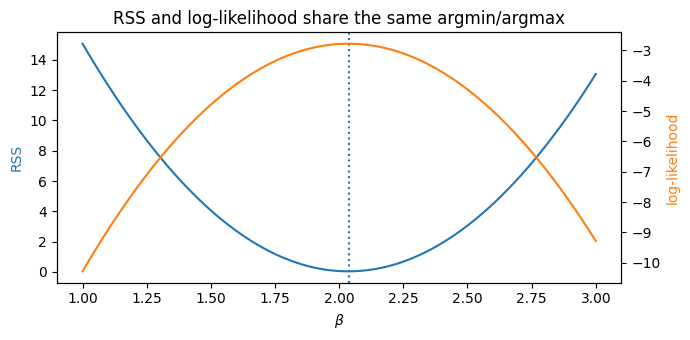

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([1.0, 2.0, 3.0])
y = np.array([2.1, 3.9, 6.2])
sigma = 1.0

betas = np.linspace(1, 3, 201)
rss_vals = [(y - b*x).dot(y - b*x) for b in betas]
loglik_vals = [-0.5*len(x)*np.log(2*np.pi*sigma**2) - 0.5/sigma**2 * (y - b*x).dot(y - b*x)
               for b in betas]

beta_rss  = betas[np.argmin(rss_vals)]
beta_loglik = betas[np.argmax(loglik_vals)]
print(f"argmin RSS:      β = {beta_rss:.3f}")
print(f"argmax log-lik:  β = {beta_loglik:.3f}")

fig, ax1 = plt.subplots(figsize=(7,3.5))
ax1.plot(betas, rss_vals, 'C0', label='RSS')
ax2 = ax1.twinx()
ax2.plot(betas, loglik_vals, 'C1', label='log-lik')
ax1.axvline(beta_rss, ls=':', c='C0')
ax1.set_xlabel(r'$\beta$'); ax1.set_ylabel('RSS', color='C0')
ax2.set_ylabel('log-likelihood', color='C1')
plt.title('RSS and log-likelihood share the same argmin/argmax');
plt.tight_layout(); plt.show()

## 6. Practice problems

### 6.1 Concept drill
> Show that the Bernoulli model $p(y\mid x,\beta)=p^y(1-p)^{1-y}$ has $\log$-likelihood $\sum_i y_i\log p_i + (1-y_i)\log(1-p_i).$

**Answer.** Apply the iid product form, then take logs term-by-term:
$$\log\prod_i p_i^{y_i}(1-p_i)^{1-y_i} = \sum_i\big[y_i\log p_i + (1-y_i)\log(1-p_i)\big].$$

### 6.2 MC style
> Which quantity is minimised in linear regression? **(A)** Log-likelihood **(B)** RSS **(C)** AIC **(D)** Classification error.

**Answer.** **(B) RSS.** Equivalent to maximising the Gaussian likelihood.

### 6.3 MC style
> Which statement about deviance is correct? **(A)** maximised during estimation, **(B)** unrelated to likelihood, **(C)** minimised to fit models, **(D)** only applies to linear regression.

**Answer.** **(C).** $\text{Dev}=-2\log L$, so minimizing deviance = maximizing log-likelihood. Applies to any parametric model, not just linear regression.

### 6.4 Paradigm identification
> A hedge fund has only equity prices for 500 stocks and wants to discover clusters of similarly-moving tickers. Which paradigm?

**Answer.** **Unsupervised** — no labels, goal is to extract low-dim structure (clusters).

### 6.5 Short derivation
> Assume $y_i \sim \mathcal N(x_i'\beta, \sigma^2)$ iid. Write $\ell(\beta)$ and explain why the $-n\log(2\pi\sigma^2)/2$ term may be dropped when *estimating* $\beta$ but **not** when computing the deviance numerically.

**Answer.** $\ell(\beta) = -\tfrac n 2\log(2\pi\sigma^2)-\tfrac{1}{2\sigma^2}\sum_i(y_i-x_i'\beta)^2.$ The first term doesn't depend on $\beta$ so it is *constant in the optimisation over $\beta$*. But the actual numerical value of $\ell$ (and thus of $\text{Dev}=-2\ell$) *does* include that term, so it cannot be ignored when you need the deviance as a number (for AIC/BIC, comparing models, etc.).